In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [3]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print('Working dir:', PROJECT_ROOT)

FIGURES_DIR = str(PROJECT_ROOT / 'reports' / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Cargar artefactos de Fase 3
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    a3 = pickle.load(f)

X_test_proc        = a3['X_test_proc']
y_test             = a3['y_test']
feature_names_proc = a3['feature_names_proc']

# Cargar artefactos de Fase 4
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl', 'rb') as f:
    a4 = pickle.load(f)

trained_models = a4['trained_models']
best_models    = a4['best_models']
cv_results     = a4['cv_results']

print('Todo cargado para Fase 5')

Working dir: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML
Todo cargado para Fase 5


---
# FASE 5 | EVALUACION (Evaluation)
---

## 5.1 Metricas en el conjunto de prueba

In [4]:
test_results = evaluate_on_test(trained_models, X_test_proc, y_test.values)


  Regresion Logistica
              precision    recall  f1-score   support

    No Viral       0.62      0.61      0.61      9999
       Viral       0.61      0.63      0.62      9999

    accuracy                           0.62     19998
   macro avg       0.62      0.62      0.62     19998
weighted avg       0.62      0.62      0.62     19998


  Random Forest
              precision    recall  f1-score   support

    No Viral       0.66      0.51      0.58      9999
       Viral       0.60      0.73      0.66      9999

    accuracy                           0.62     19998
   macro avg       0.63      0.62      0.62     19998
weighted avg       0.63      0.62      0.62     19998


  Gradient Boosting
              precision    recall  f1-score   support

    No Viral       0.66      0.53      0.59      9999
       Viral       0.61      0.72      0.66      9999

    accuracy                           0.63     19998
   macro avg       0.63      0.63      0.62     19998
weighted avg 

In [5]:
print('\nTabla de Metricas - Conjunto de Prueba:')
display(test_results.round(4))


Tabla de Metricas - Conjunto de Prueba:


,Accuracy,F1,ROC-AUC,Precision,Recall
Modelo,,,,,
Regresion Logistica,0.6158,0.6195,0.6669,0.6135,0.6256
Random Forest,0.6242,0.6615,0.6805,0.6017,0.7344
Gradient Boosting,0.6261,0.6588,0.6816,0.6058,0.7221
Hist Gradient Boosting,0.6233,0.6571,0.6803,0.6030,0.7219


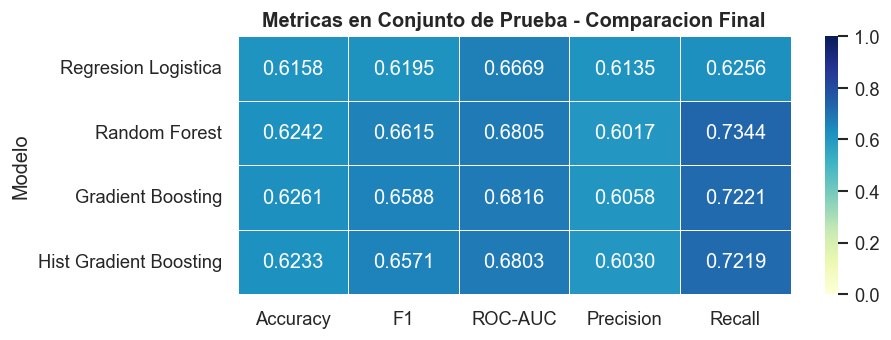

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/metrics_heatmap.png


In [6]:
plot_metrics_heatmap(test_results, save_path=f'{FIGURES_DIR}/metrics_heatmap.png')

## 5.2 Matrices de confusión

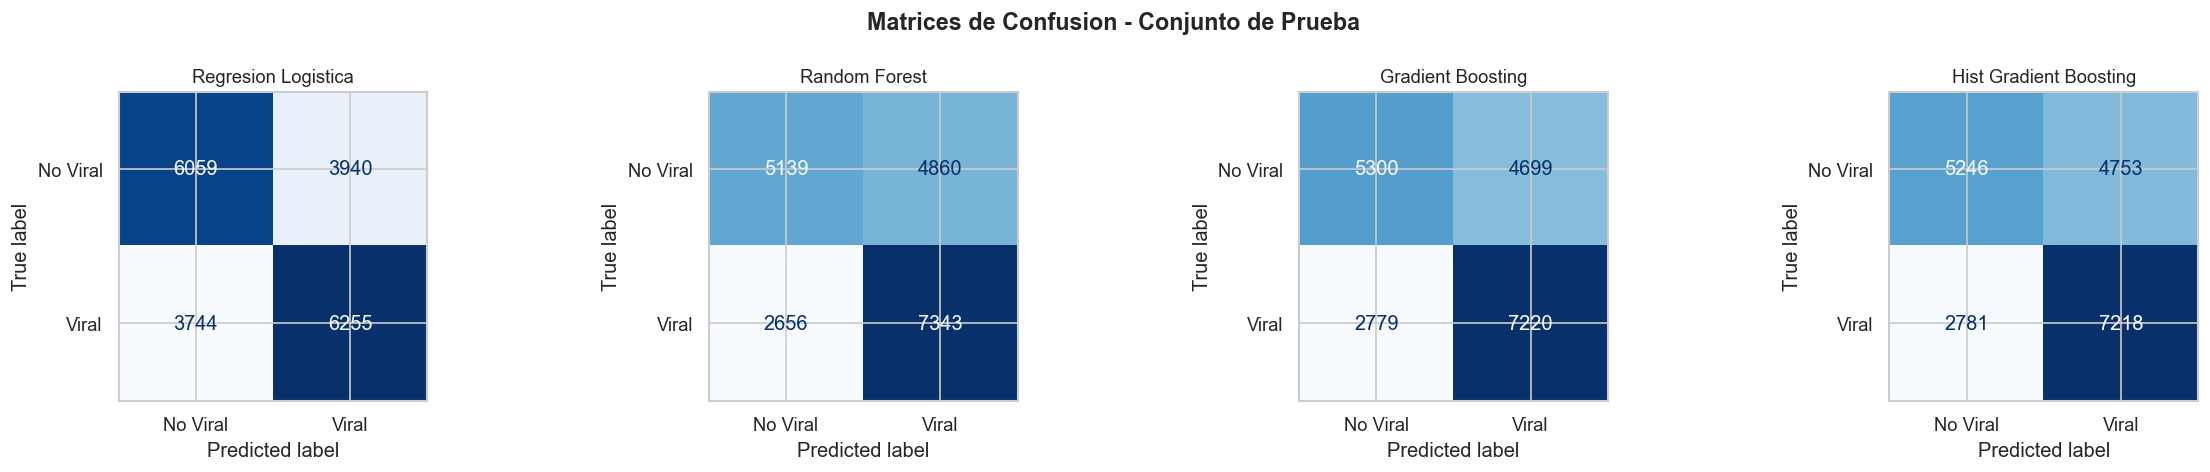

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/confusion_matrices.png


In [7]:
plot_confusion_matrices(trained_models, X_test_proc, y_test.values,
                         save_path=f'{FIGURES_DIR}/confusion_matrices.png')

## 5.3 Curvas ROC

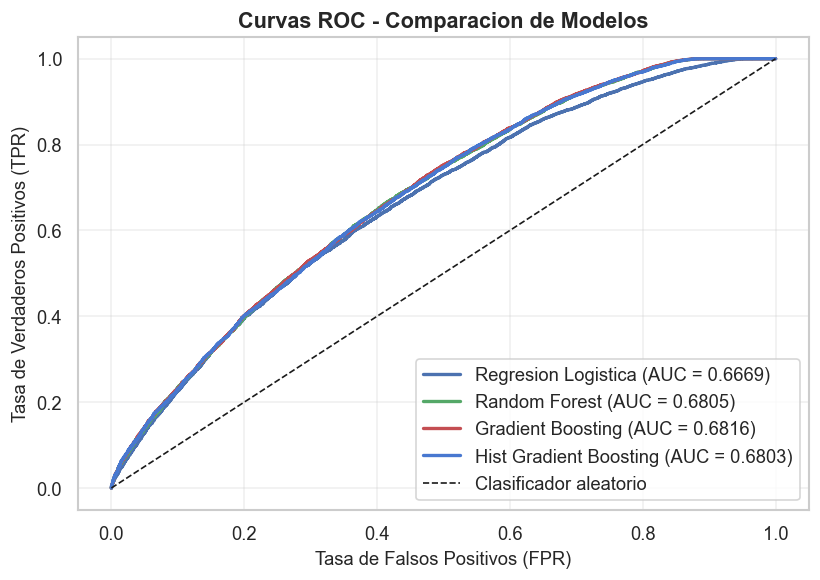

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/roc_curves.png


In [8]:
plot_roc_curves(trained_models, X_test_proc, y_test.values,
                save_path=f'{FIGURES_DIR}/roc_curves.png')

## 5.4 Importancia de caracteristicas

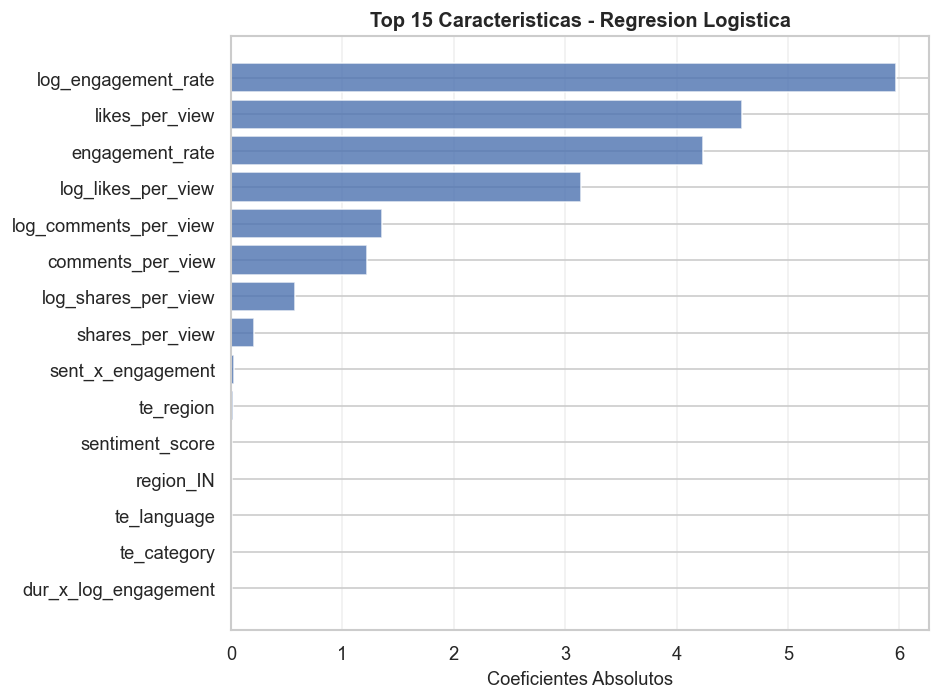

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/feature_importance_regresion_logistica.png


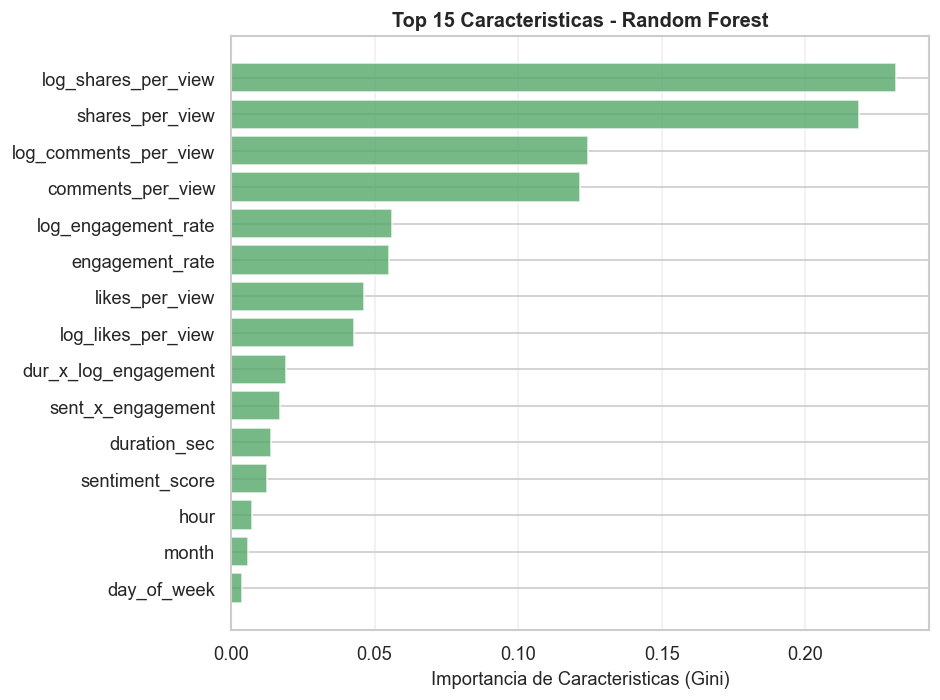

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/feature_importance_random_forest.png


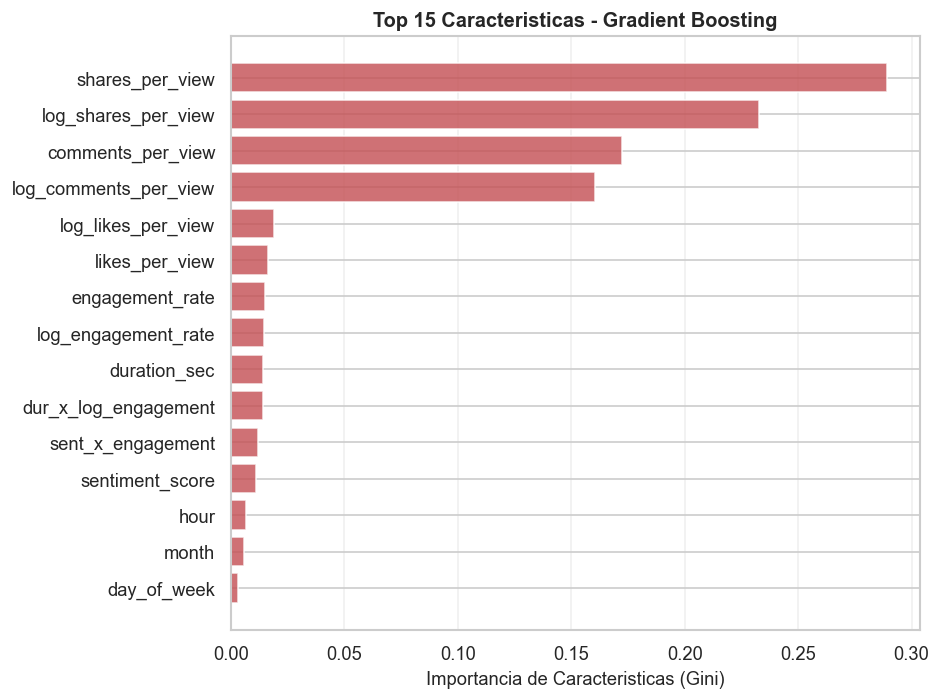

[INFO] Figura guardada: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\reports\figures/feature_importance_gradient_boosting.png
[WARN] El modelo Hist Gradient Boosting no tiene importancias ni coeficientes.


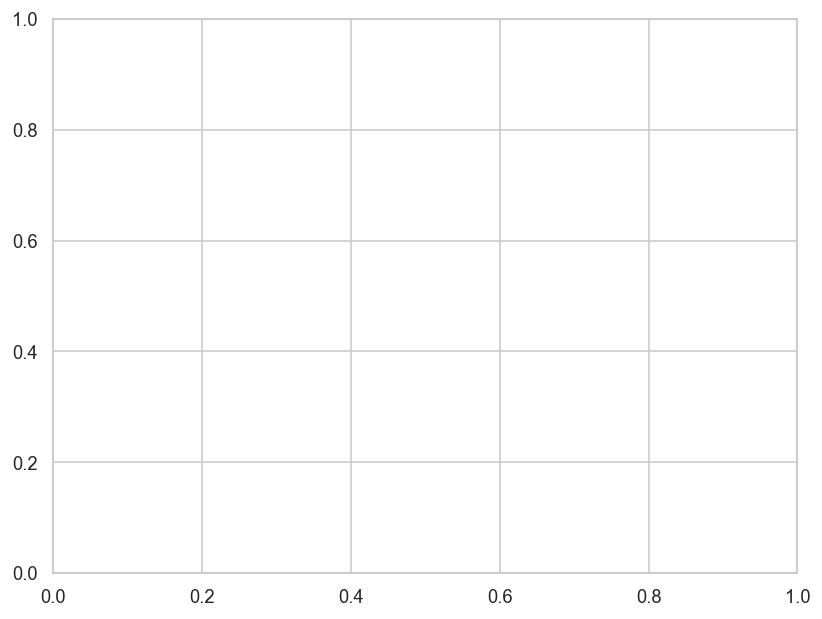

In [9]:
for name, model in trained_models.items():
    plot_feature_importance(
        model, feature_names_proc, name, top_n=15,
        save_path=f'{FIGURES_DIR}/feature_importance.png'
    )

## 5.5 Comparación global y selección del mejor modelo

In [10]:
# Comparacion: CV vs Test
summary = pd.DataFrame({
    'CV ROC-AUC': cv_results['ROC-AUC (val)'],
    'Test ROC-AUC': test_results['ROC-AUC'],
    'CV F1': cv_results['F1 (val)'],
    'Test F1': test_results['F1'],
    'Test Accuracy': test_results['Accuracy'],
})

print('Comparacion CV vs Conjunto de Prueba:')
display(summary.round(4))

mejor_modelo = test_results['ROC-AUC'].idxmax()
mejor_auc    = test_results.loc[mejor_modelo, 'ROC-AUC']

print(f'\nMejor modelo (por ROC-AUC en prueba): {mejor_modelo}')
print(f'ROC-AUC = {mejor_auc:.4f}')

Comparacion CV vs Conjunto de Prueba:


,CV ROC-AUC,Test ROC-AUC,CV F1,Test F1,Test Accuracy
Regresion Logistica,0.6650,0.6669,0.6189,0.6195,0.6158
Random Forest,0.6788,0.6805,0.6611,0.6615,0.6242
Gradient Boosting,0.6796,0.6816,0.6573,0.6588,0.6261
Hist Gradient Boosting,0.6788,0.6803,0.6560,0.6571,0.6233



Mejor modelo (por ROC-AUC en prueba): Gradient Boosting
ROC-AUC = 0.6816


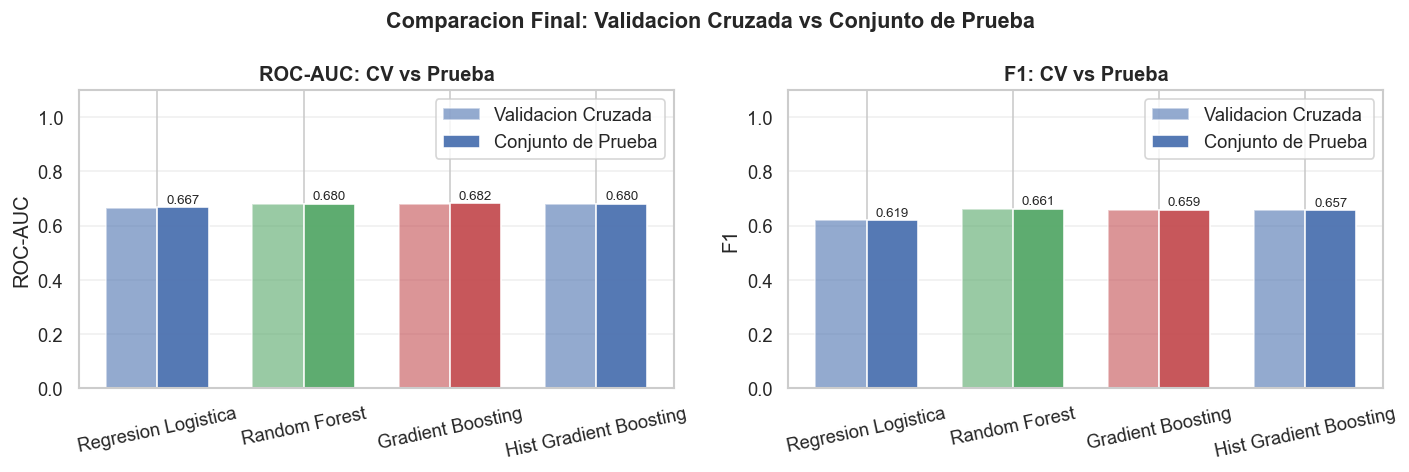

In [11]:
# Grafica de barras lado a lado: CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['ROC-AUC', 'F1']):
    cv_vals   = summary[f'CV {metric}'].values
    test_vals = summary[f'Test {metric}'].values
    x = np.arange(len(summary))
    w = 0.35

    bars1 = ax.bar(x - w/2, cv_vals,   w, label='Validacion Cruzada',
                   color=model_colors, alpha=0.6)
    bars2 = ax.bar(x + w/2, test_vals, w, label='Conjunto de Prueba',
                   color=model_colors, alpha=0.95)

    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric}: CV vs Prueba', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bar, val in zip(bars2, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparacion Final: Validacion Cruzada vs Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comparacion_final.png', bbox_inches='tight')
plt.show()

## 5.6 Optimización del Umbral de Decisión

Por defecto los clasificadores usan umbral = 0.5. Optimizarlo maximiza el F1-score
en el conjunto de prueba sin reentrenar el modelo. Esto es especialmente útil cuando
el costo de falsos positivos y falsos negativos no es simétrico.


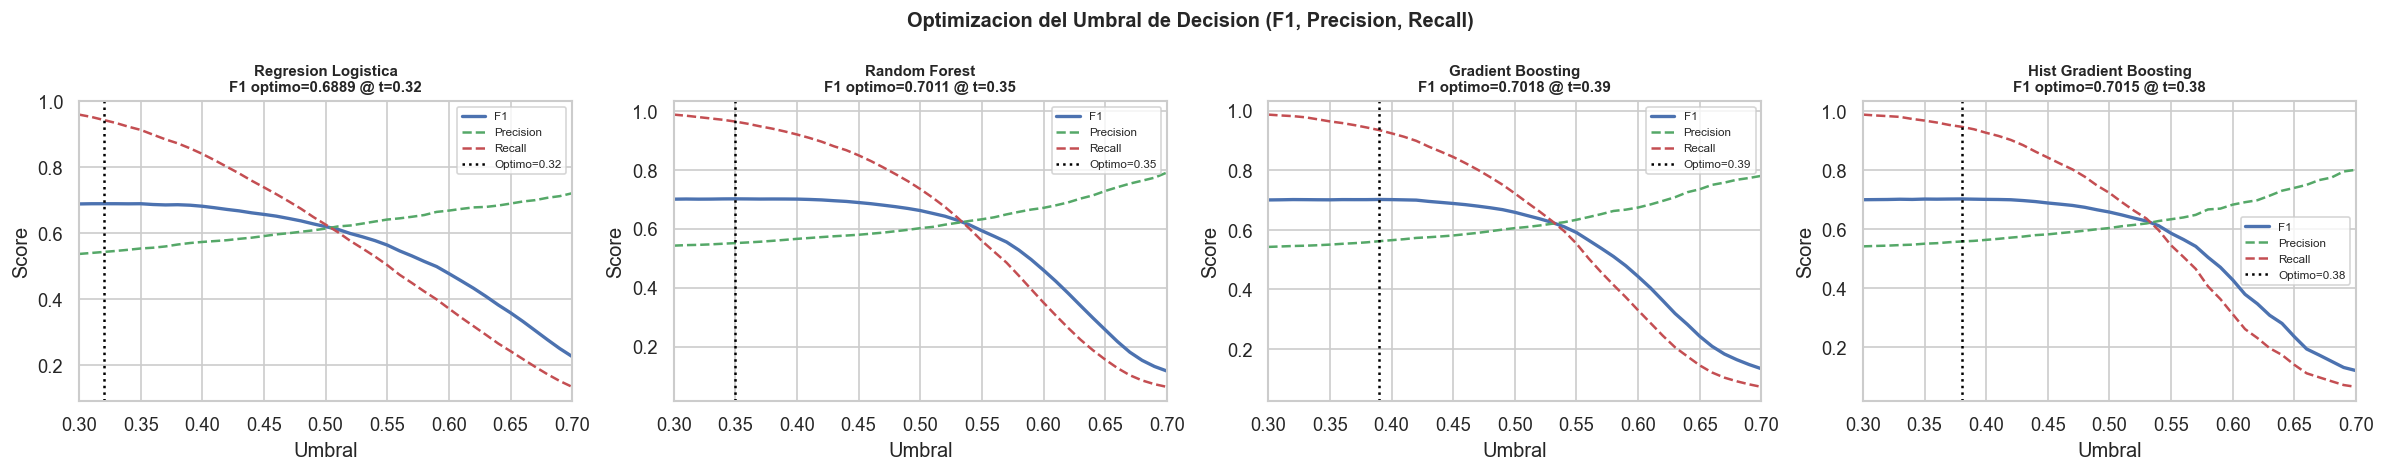


Umbrales optimos por modelo:
  Regresion Logistica           : umbral=0.32  F1=0.6889
  Random Forest                 : umbral=0.35  F1=0.7011
  Gradient Boosting             : umbral=0.39  F1=0.7018
  Hist Gradient Boosting        : umbral=0.38  F1=0.7015


In [12]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

umbral_results = {}
thresholds     = np.arange(0.30, 0.71, 0.01)

fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    proba = model.predict_proba(X_test_proc)[:, 1]

    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        f1s.append(f1_score(y_test, preds, zero_division=0))
        precs.append(precision_score(y_test, preds, zero_division=0))
        recs.append(recall_score(y_test, preds, zero_division=0))

    best_t = thresholds[np.argmax(f1s)]
    best_f1 = max(f1s)
    umbral_results[name] = {'umbral_optimo': best_t, 'F1_optimo': best_f1}

    ax.plot(thresholds, f1s,   label='F1',        color='#4C72B0', lw=2)
    ax.plot(thresholds, precs, label='Precision',  color='#55A868', lw=1.5, linestyle='--')
    ax.plot(thresholds, recs,  label='Recall',     color='#C44E52', lw=1.5, linestyle='--')
    ax.axvline(best_t, color='black', linestyle=':', lw=1.5, label=f'Optimo={best_t:.2f}')
    ax.set_title(f'{name}\nF1 optimo={best_f1:.4f} @ t={best_t:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Umbral'); ax.set_ylabel('Score')
    ax.legend(fontsize=7); ax.set_xlim(0.30, 0.70)

plt.suptitle('Optimizacion del Umbral de Decision (F1, Precision, Recall)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/threshold_optimization.png', bbox_inches='tight')
plt.show()

print('\nUmbrales optimos por modelo:')
for name, res in umbral_results.items():
    print(f'  {name:30}: umbral={res["umbral_optimo"]:.2f}  F1={res["F1_optimo"]:.4f}')

In [13]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'test_results':    test_results,
        'mejor_modelo':    mejor_modelo,
        'mejor_auc':       mejor_auc,
        'umbral_results':  umbral_results,
    }, f)

print('Guardado en:', PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl')

Guardado en: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\data\processed\fase5_artifacts.pkl
